In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from pathlib import Path

seed = 2026
np.random.seed(seed)

In [2]:
def print_dir(obj):
    for i in dir(obj):
        if i.startswith("_"):
            continue
        print(i)

In [3]:
# BASE = '/kaggle/input/competitions/buried-fault-aicc-round-9'
BASE = Path.cwd().parent / "data"
# print_dir(BASE)

train = np.load(f'{BASE}\\train.npy')
test = np.load(f'{BASE}\\test.npy')

train_meta = pd.read_csv(f'{BASE}/train_meta.csv')
test_meta = pd.read_csv(f'{BASE}/test_meta.csv')

ytr = train_meta['label'].to_numpy()

print(train.shape, test.shape, 'classes', np.bincount(ytr))

(2400, 6, 2048) (1800, 6, 2048) classes [435 327 409 384 463 382]


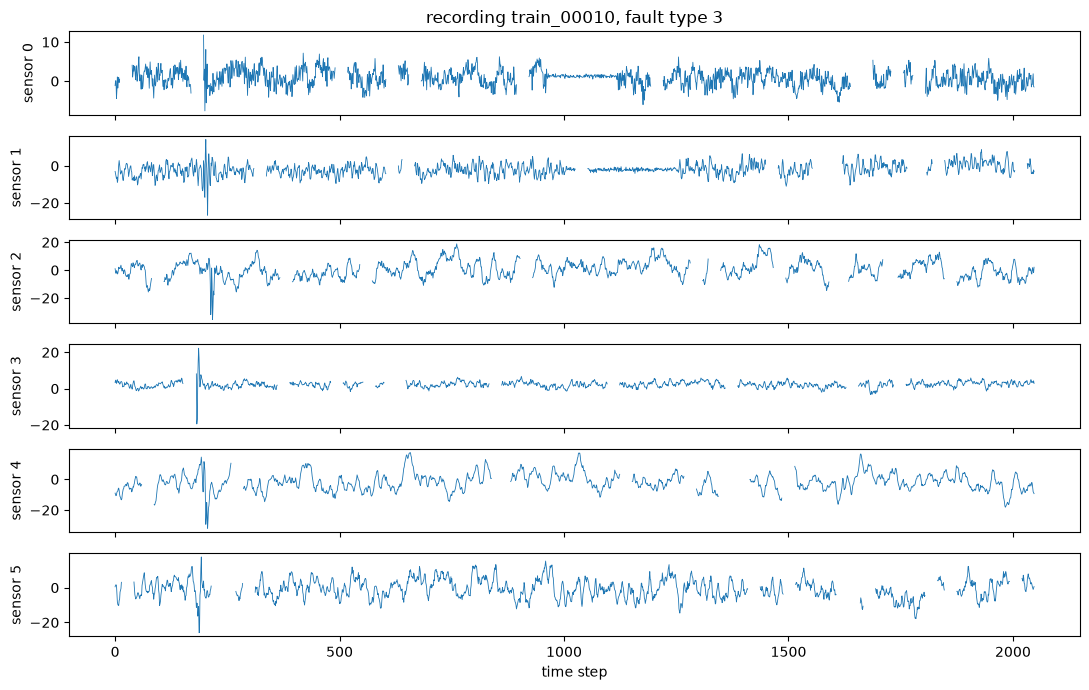

In [10]:
import matplotlib.pyplot as plt

i = 10
fig, axes = plt.subplots(6, 1, figsize=(11, 7), sharex=True)
for c in range(6):
    axes[c].plot(train[i, c], lw=0.6)
    axes[c].set_ylabel(f'sensor {c}')
axes[0].set_title(f"recording {train_meta['recording_id'][i]}, fault type {ytr[i]}")
axes[-1].set_xlabel('time step')
plt.tight_layout()
plt.show()

In [5]:
print('missing fraction per channel:', np.round(np.isnan(train[i]).mean(1), 3))
print('missing fraction overall:', round(float(np.isnan(train).mean()), 3))

missing fraction per channel: [0.155 0.148 0.145 0.148 0.14  0.143]
missing fraction overall: 0.147


In [6]:
def time_stats(X):
    dx = np.diff(X, axis=-1)
    return [X.mean(-1), X.std(-1), X.min(-1), X.max(-1),
            np.percentile(X, 25, -1), np.percentile(X, 75, -1),
            dx.std(-1), np.abs(dx).max(-1)]

def band_energies(X, n_bands=8):
    power = np.abs(np.fft.rfft(X, axis=-1)) ** 2
    edges = np.linspace(0, power.shape[-1], n_bands + 1).astype(int)
    return [np.log(power[..., edges[b]:edges[b + 1]].mean(-1)) for b in range(n_bands)]

def feats(X):
    X = np.nan_to_num(X, nan=0.0)
    parts = time_stats(X) + band_energies(X)
    return np.concatenate([p.reshape(len(X), -1) for p in parts], axis=1)

Ftr, Fte = feats(train), feats(test)
print('feature dim', Ftr.shape[1])

feature dim 96


In [7]:
scaler = StandardScaler().fit(Ftr)

# clf = HistGradientBoostingClassifier()
clf = RandomForestClassifier()


clf.fit(scaler.transform(Ftr), ytr)

pred = clf.predict(scaler.transform(Fte))

print('predicted class balance', np.bincount(pred, minlength=6))

predicted class balance [193 206 278 417 306 400]


## Submission

Fixed central interval for every recording, since this baseline does not localize.

In [8]:
T = train.shape[-1]

sub = pd.DataFrame({
    'recording_id': test_meta['recording_id'],
    'label': pred.astype(int),
    'start': int(T * 0.33),
    'end': int(T * 0.66),
})

sub.to_csv(Path.cwd().parent / 'submission.csv', index=False)
sub.head()

,recording_id,label,start,end
0,test_00000,4,675,1351
1,test_00001,5,675,1351
2,test_00002,2,675,1351
3,test_00003,4,675,1351
4,test_00004,0,675,1351
